# Results Analytics

Load data and add various properties

In [4]:
import pandas as pd 
import numpy as np

lsc22 = pd.read_csv('lsc22_detailed_scores.csv')
lsc23 = pd.read_csv('lsc23_detailed_scores.csv')
lsc24_novice = pd.read_csv('lsc24_novice_detailed_scores.csv')
lsc24_expert = pd.read_csv('lsc24_expert_detailed_scores.csv')

# For lsc22, every task is expert
lsc22["novice"] = False
# For year lsc23, if task ends with "N", it is a novice task
lsc23["novice"] = lsc23["task"].str.endswith("N")
lsc24_novice["novice"] = True
lsc24_expert["novice"] = False

# Add years
lsc22['year'] = 2022
lsc23['year'] = 2023
lsc24_novice['year'] = 2024
lsc24_expert['year'] = 2024

# Concatenate
lsc = pd.concat([lsc22, lsc23, lsc24_novice, lsc24_expert])
lsc["time_till_correct"] = lsc["time_till_correct"].replace([np.inf, -np.inf], np.nan)
lsc

,Unnamed: 0,team,task,task_type,score,incorrect,correct,time_till_correct,novice,year
0,0,MyScéal,LSC22-KIS01,KIS,93.672333,0,1,37.966,False,2022
1,1,LifeSeeker,LSC22-KIS01,KIS,96.762833,0,1,19.423,False,2022
2,2,MEMENTO,LSC22-KIS01,KIS,93.183667,0,1,40.898,False,2022
3,3,FIRST,LSC22-KIS01,KIS,90.453333,0,1,57.280,False,2022
4,4,Voxento,LSC22-KIS01,KIS,89.969333,2,1,57.784,False,2022
...,...,...,...,...,...,...,...,...,...,...
555,555,vitrivr,LSC24-QA05,QA,66.029833,1,1,143.821,False,2024
556,556,Voxento,LSC24-QA05,QA,87.235000,0,1,76.590,False,2024
557,557,MyEachtra,LSC24-QA05,QA,88.562167,0,1,68.627,False,2024
558,558,PraK3,LSC24-QA05,QA,87.463667,0,1,75.218,False,2024


In [5]:
# Print the number of unique teams per year (minus novice)
print(lsc[lsc["novice"] == False].groupby("year")["team"].nunique())

year
2022     9
2023    14
2024    35
Name: team, dtype: int64


In [6]:
def calculate_precision(row):
    total = row["incorrect"] + row["correct"]
    if total == 0:
        return 0
    return row["correct"] / total
lsc["precision"] = lsc.apply(lambda x: calculate_precision(x), axis=1)
lsc.to_csv('lsc_detailed_scores.csv', index=False)   

## Graphs

In [7]:
# Settings for figures
from enum import Enum

from pydantic import BaseModel
SCALE = 2
FIGURE_SIZE_ONE_COL = 3.5 * SCALE
FIGURE_SIZE_TWO_COL = 7.16 * SCALE
FONT_SIZE = 8


class Color(Enum):
    orange = "#fdb462"
    pink = "#decbe4"
    blue = "#b3cde3"
    green = "#ccebc5"
    light = "#DEF4FA"
    red = "#fbb4ae"



In [33]:
from tkinter import font
from turtle import position
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches


plt.rcParams.update(
    {
        "font.family": "serif",  # Or 'DejaVu Serif', 'Times New Roman'
        "font.size": 16,
        "pdf.fonttype": 42,  # Use TrueType fonts in PDF (not Type 3)
        "ps.fonttype": 42,
    }
)

def plot_columns_by_year(
    df, column1: str, column2: str, title: str, include_novice=False
):
    fig = plt.figure(figsize=(FIGURE_SIZE_TWO_COL, FIGURE_SIZE_ONE_COL))
    for i, task in enumerate(df["task_type"].unique()):
        ax = fig.add_subplot(1, 3, i + 1)
        # Filter data for the task type
        data = df[df["task_type"] == task]
        if not include_novice:
            data = data[data["novice"] == False]
        data = data.dropna(subset=[column1, column2])

        # Prepare boxplots
        years = data["year"].unique()
        years.sort()

        # Prepare the data for plotting
        data_long = pd.melt(
            data,
            id_vars=["year"],
            value_vars=[column1, column2, "precision"] if task != "AD" else [column1, column2],
            var_name="Metric",
            value_name="Value",
        )
        if task == "AD":
            sns.boxplot(
                data=data_long,
                x="year",
                y="Value",
                hue="Metric",
                palette={column1: Color.green.value, column2: Color.orange.value, "precision": Color.blue.value},
                width=0.5,
                ax=ax,
                showmeans=False,  # Focus on quartiles only
                showfliers=False,
                legend=False,
                gap=0.1,
            )
            ax.set_xticks(range(0, len(years)))
            ax.set_xticklabels(years)
        else:
            sns.barplot(
                data=data_long,
                x="year",
                y="Value",
                hue="Metric",
                palette={column1: Color.green.value, column2: Color.orange.value, "precision": Color.blue.value},
                ax=ax,
                width=0.7,
                gap=0.05,
                err_kws={"linewidth": 1.5, "color": "gray"},
                legend=False,
            )
            ax.set_ylim(0, 1.25)
            # # Write the values on top of the bars
            # for p in ax.patches:
            #     ax.annotate(
            #         f"{p.get_height():.2f}",
            #         (p.get_x() + p.get_width() / 2, p.get_height() + 0.05),
            #         ha="center",
            #         va="bottom",
            #         fontsize=8,
            #     )
                

        precision_column = "precision"
        # Move the precision data to the right
        precision_data = data.dropna(subset=[precision_column])
        precision_data["new_year"] = precision_data["year"] + 0.3

        if task == "AD":
            # Add a secondary y-axis for precision
            ax2 = ax.twinx()
            sns.boxplot(
                data=precision_data,
                x="year",
                y=precision_column,
                ax=ax2,
                color=Color.blue.value,
                width=0.2,  # Adjust width to prevent overlap
                showmeans=True,  # Highlight mean for precision
                positions=[0.3, 1.3, 2.3],
            )            
            ax2.tick_params(axis="y", colors="#2C6B78FF")
            ax2.set_ylabel("Precision", color="#2C6B78FF")

        ax.set_title(label=task)
        if i == 0:
            ax.set_ylabel(ylabel="Values")
        else:
            ax.set_ylabel("")

        if i == 1:
            ax.set_xlabel("")
        else:
            ax.set_xlabel("")

    # Add a legend
    correct = mpatches.Patch(color=Color.green.value, label="Correct")
    incorrect = mpatches.Patch(color=Color.orange.value, label="Incorrect")
    precision = mpatches.Patch(color=Color.blue.value, label="Precision")

    plt.legend(handles=[correct, incorrect, precision], loc="upper right", bbox_to_anchor=(1.0, 1.2), ncol=3,
               fontsize=16)
    # ax.legend([box1["boxes"][0], box2["boxes"][0]], [column1, column2])
    my_suptitle = plt.suptitle(title, y=1.10, fontsize=24, fontweight="bold")
    plt.savefig(
        "graphs/" + title.lower().replace(" ", "_") + ".pdf",
        dpi=300,
        bbox_inches="tight",
        bbox_extra_artists=[my_suptitle],
    )

In [ ]:
# Plot precisions over the years (distribution) based on tasks
plot_columns_by_year(lsc, "correct", "incorrect", title="Correct and incorrect by task type and year")

In [ ]:
import matplotlib.pyplot as plt

def plot_column_by_year(df, column: str, title: str, include_novice=False):
    plt.style.use("default")
    plt.rcParams.update(
    {
        "font.family": "serif",  # Or 'DejaVu Serif', 'Times New Roman'
        "font.size": 10,
        "pdf.fonttype": 42,  # Use TrueType fonts in PDF (not Type 3)
        "ps.fonttype": 42,
    }
)
    fig = plt.figure(figsize=(FIGURE_SIZE_ONE_COL * 4 / 3, FIGURE_SIZE_ONE_COL))
    for i, task in enumerate(df['task_type'].unique()):
        ax = fig.add_subplot(1, 3, i+1)
        # Remove novice tas54ks
        data = df[df['task_type'] == task]
        if not include_novice:
            data = data[data['novice'] == False]
        data = data.dropna(subset=[column])
        data.boxplot(column, by="year", ax=ax, grid=False)
        ax.set_title(label=task)
    my_suptitle = plt.suptitle(title, y=1.02, fontsize=16)
    plt.savefig("graphs/" + title.lower().replace(" ", "_") + ".pdf", dpi=300, bbox_inches='tight',bbox_extra_artists=[my_suptitle])

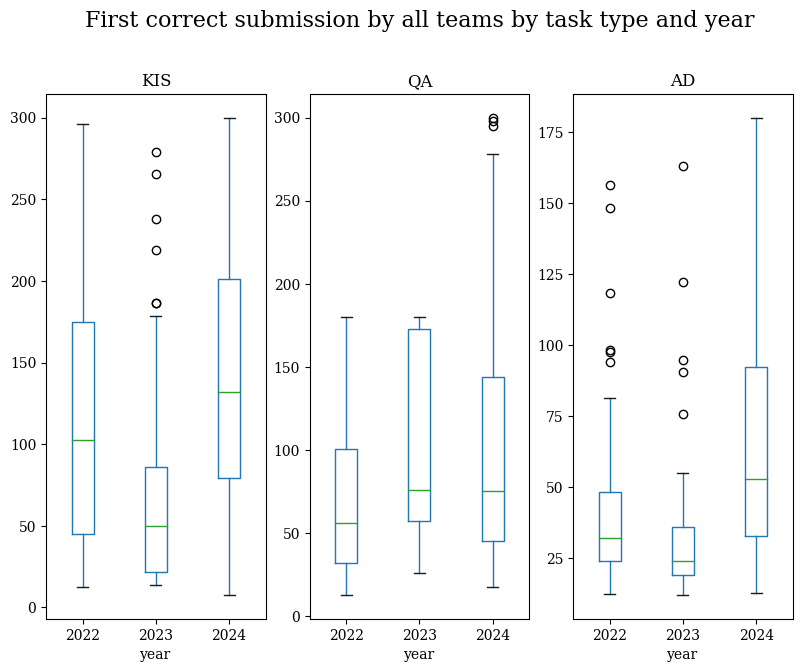

In [ ]:
plot_column_by_year(lsc, "time_till_correct", "First correct submission by all teams by task type and year", include_novice=False)

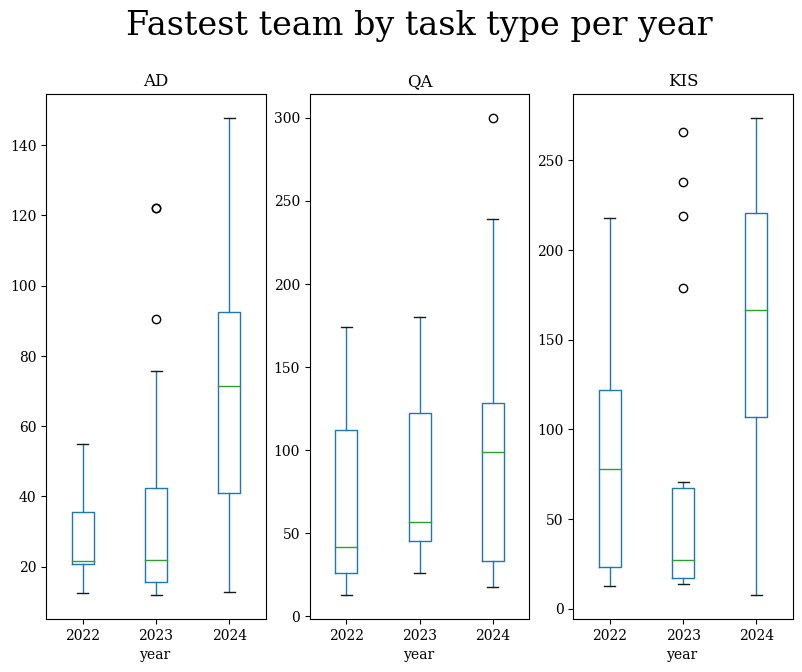

In [ ]:
# Choose the best team for each task (time_till_correct)
# Drop Nan values
time = lsc.dropna(subset=['time_till_correct'])
# Plot the best team for each task
time = time.loc[time.groupby(by='task')['time_till_correct'].idxmin()]
plot_column_by_year(time, "time_till_correct", "Fastest team by task type per year")

In [ ]:
def remove_team_number(team):
    if team[-1].isdigit():
        return team[:-1]
    return team
merged_teams = lsc.copy()
merged_teams['team'] = lsc['team'].apply(remove_team_number)

In [ ]:
def change_team_name(team):
    name_changes = {
        "2022 Baseline": "MyScéal",
        "Memoria-MEO4J": "Memoria",
        "e-LifeSeeker": "LifeSeeker",
        "Vitrivr-Hybrid": "vitrivr-Hybrid",
        "LIFEXPLORE": "lifeXplore",
        "First": "FIRST",
        "Lifegraph": "LifeGraph",
        "MEMENTO": "Memento",
        "MEMORIA": "Memoria",
    }

    if team in name_changes:
        return name_changes[team]
    return team

merged_teams['team'] = merged_teams['team'].apply(change_team_name)

In [ ]:
TEAMS = merged_teams['team'].unique()
YEARS = merged_teams['year'].unique()

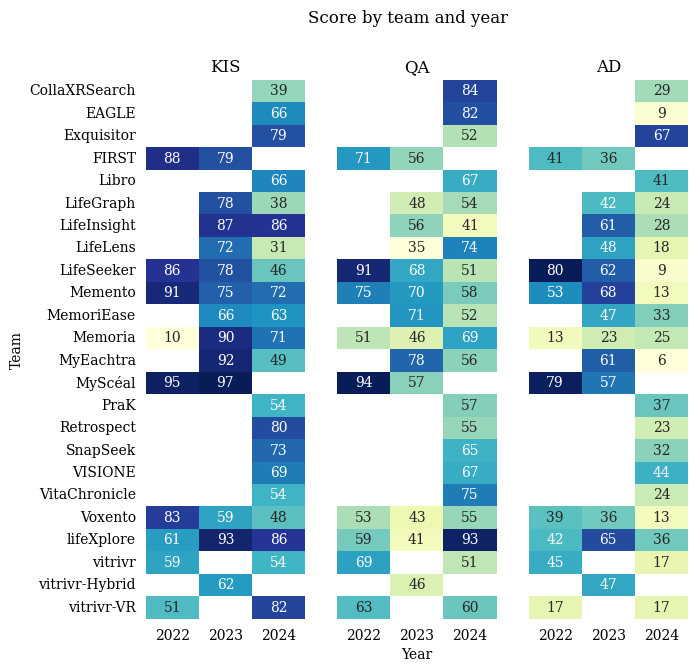

In [ ]:
# Map score by team and year
# Normalize score (best score in each task is 100)
import seaborn as sns
import matplotlib.pyplot as plt

merged_teams["score"] = merged_teams["score"].replace([np.inf, -np.inf], np.nan)
merged_teams["score"] = merged_teams["score"].fillna(0)
merged_teams["score"] = merged_teams.groupby(["task", "year"])["score"].transform(lambda x: x / x.max() * 100)

fig = plt.figure(figsize=(FIGURE_SIZE_ONE_COL, FIGURE_SIZE_ONE_COL))
plt.rcParams.update(
    {
        "font.family": "serif",  # Or 'DejaVu Serif', 'Times New Roman'
        "font.size": 10,
        "pdf.fonttype": 42,  # Use TrueType fonts in PDF (not Type 3)
        "ps.fonttype": 42,
    }
)
for i, task in enumerate(merged_teams["task_type"].unique()):
    ax = fig.add_subplot(1, 3, i + 1)
    data = merged_teams[merged_teams["task_type"] == task]
    data = data[data["novice"] == False]
    data = data.dropna(subset=["score"])
    sns.heatmap(
        data.pivot_table(index="team", columns="year", values="score", aggfunc="mean"),
        cmap="YlGnBu",
        annot=True,
        fmt=".0f",
        ax=ax,
        cbar=False,
    )
    ax.tick_params(left=False, bottom=False)  ## other options are right and top

    if i == 0:
        ax.set_ylabel("Team")
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])
    if i == 1:
        ax.set_xlabel("Year")
    else:
        ax.set_xlabel("")
    ax.set_title(task)
my_suptitle = plt.suptitle("Score by team and year")
plt.savefig("graphs/score_by_team_and_year.png", dpi=300, bbox_inches='tight',bbox_extra_artists=[my_suptitle])

In [ ]:
def count_years(team):
    return len(merged_teams[merged_teams["team"] == team]["year"].unique())
regular_teams = [team for team in TEAMS if count_years(team) >=2]
regular_teams += ["vitrivr-Hybrid"]

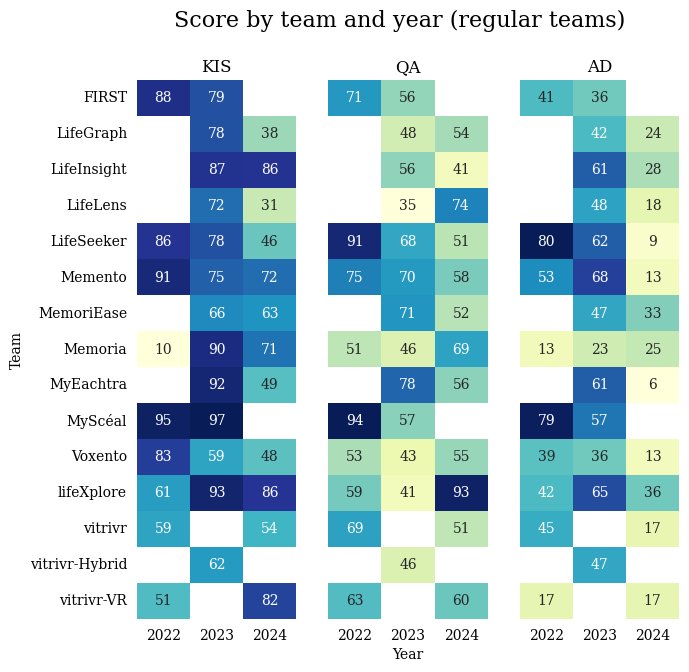

In [ ]:
# Map score by team and year
from tkinter import font


fig = plt.figure(figsize=(FIGURE_SIZE_ONE_COL, FIGURE_SIZE_ONE_COL))
for i, task in enumerate(merged_teams["task_type"].unique()):
    ax = fig.add_subplot(1, 3, i + 1)
    data = merged_teams[merged_teams["task_type"] == task]
    data = data[data["novice"] == False]
    data = data.dropna(subset=["score"])
    # Remove teams that only participated in one year
    data = data[data["team"].isin(regular_teams)]
    # sort by team
    data = data.sort_values(by="team")
    sns.heatmap(
        data.pivot_table(index="team", columns="year", values="score", aggfunc="mean"),
        cmap="YlGnBu",
        annot=True,
        fmt=".0f",
        ax=ax,
        cbar=False,
    )
    ax.tick_params(left=False, bottom=False)  ## other options are right and top
    if i == 0:
        ax.set_ylabel("Team")
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])
    if i == 1:
        ax.set_xlabel("Year")
    else:
        ax.set_xlabel("")
    ax.set_title(task)

my_suptitle = plt.suptitle("Score by team and year (regular teams)", fontsize=16)
plt.savefig("graphs/score_by_team_and_year_regular.pdf", dpi=300, bbox_inches='tight',bbox_extra_artists=[my_suptitle])

# Query analysis

In [ ]:
import json
from turtle import color
sns.set_theme(style="whitegrid")

lsc22_tasks = json.load(open("LSC22_tasks.json"))
lsc23_tasks = json.load(open("LSC23_tasks.json"))
lsc24_tasks = json.load(open("LSC24_Expert_tasks.json"))
# remove lsc23 novice tasks
lsc23_tasks = [task for task in lsc23_tasks if not task["name"].endswith("N")]
lsc22_tasks = [{**task, "year": 2022} for task in lsc22_tasks]
lsc23_tasks = [{**task, "year": 2023} for task in lsc23_tasks]
lsc24_tasks = [{**task, "year": 2024} for task in lsc24_tasks]
lsc_tasks = lsc22_tasks + lsc23_tasks + lsc24_tasks
# Do query get more specific (num of groundtruth) - KIS - Adhoc
tasks = [task for task in lsc_tasks if "QA" not in task["name"]]  # type: ignore

def count_groundtruth(task):
    return len(task["targets"])

def task_type(name):
    if "QA" in name:
        return "QA"
    elif "KIS" in name:
        return "KIS"
    return "AD"

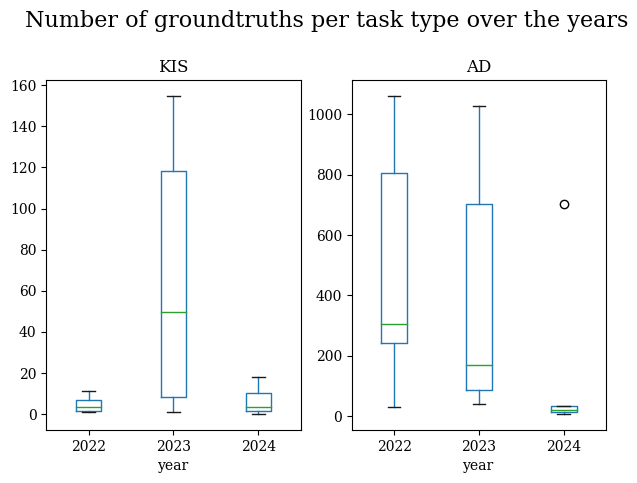

In [ ]:
from matplotlib import style

data = pd.DataFrame(tasks)

data["num_groundtruth"] = data.apply(count_groundtruth, axis=1)
# remove outlier > 700
data["num_groundtruth"] = data["num_groundtruth"].astype(int)
# data = data[data["num_groundtruth"] < 700]
data["task_type"] = data["name"].apply(task_type)
fig = plt.figure(figsize=(FIGURE_SIZE_ONE_COL, FIGURE_SIZE_ONE_COL * 2 / 3))

style.use("default")
plt.rcParams.update(
    {
        "font.family": "serif",  # Or 'DejaVu Serif', 'Times New Roman'
        "font.size": 10,
        "pdf.fonttype": 42,  # Use TrueType fonts in PDF (not Type 3)
        "ps.fonttype": 42,
    }
)

for i, task in enumerate(data["task_type"].unique()):
    ax = fig.add_subplot(1, 2, i + 1)
    data[data["task_type"] == task].boxplot(
        column="num_groundtruth",
        by="year",
        ax=ax,
        grid=False,
    )
    ax.set_title(task)
my_suptitle = plt.suptitle(
    t="Number of groundtruths per task type over the years", y=1.05, fontsize=16
)
fig.savefig(
    "graphs/num_groundtruths.pdf",
    dpi=300,
    bbox_inches="tight",
    bbox_extra_artists=[my_suptitle],
)

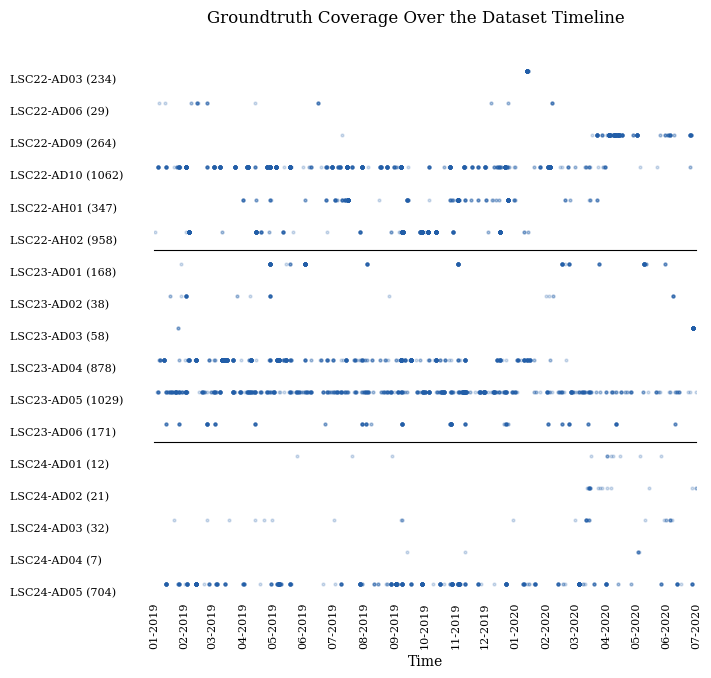

In [ ]:
from datetime import datetime
def target_to_time(img_id):
    # remove extension
    img_id = img_id.split(".")[0]
    # remove dir
    img_id = img_id.split("/")[-1]
    # convert to datetime
    return datetime.strptime(img_id, "%Y%m%d_%H%M%S_000")

# Map the targets of each task to time
time_start = datetime(2019, 1, 1)
time_end = datetime(2020, 7, 1)

fig = plt.figure(figsize=(FIGURE_SIZE_ONE_COL, FIGURE_SIZE_ONE_COL))

# sort tasks by year, task_type, and name
tasks = sorted(tasks, key=lambda x: (x["year"], task_type(x["name"]), x["name"]))
# Include only adhoc
tasks = [task for task in tasks if task_type(task["name"]) == "AD"]
current_year = 2022
for i, task in enumerate(tasks):
    ax = fig.add_subplot(len(tasks), 1, i + 1)
    # Get the targets
    targets: list = task["targets"] # type: ignore
    # Convert to time
    times = [target_to_time(target) for target in targets]
    # Filter by time
    times = [time for time in times if time_start <= time <= time_end]
    if len(times) > 0:
        # Convert time to position
        positions = [(time - time_start).total_seconds() for time in times]
        if task_type(task["name"]) == "AD":
            ax.scatter(positions, [0] * len(times), s=4, alpha=0.2, color="#225ea8")
        else:
            ax.scatter(positions, [0] * len(times), s=8, alpha=0.75, color="#fdb462")

    ax.set_ylabel(f"{task['name']} ({len(task['targets'])})", rotation=0, fontsize=8, loc="bottom", labelpad=100)

    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.set_xlim(0, (time_end - time_start).total_seconds())
    # remove box
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(b=False)
    ax.spines["bottom"].set_visible(False)
    if task["year"] != current_year:
        ax.spines["top"].set_visible(True)
        current_year = task["year"]
    
    ax.tick_params(axis="both", which="both", length=0)

ax.set_xlabel("Time")
# set ticks as months
months = pd.date_range(time_start, time_end, freq="MS")
ax.set_xticks([(time - time_start).total_seconds() for time in months])
ax.set_xticklabels([time.strftime("%m-%Y") for time in months], rotation=90, fontsize=8)
my_suptitle = plt.suptitle("Groundtruth Coverage Over the Dataset Timeline", y=0.95)
fig.savefig("graphs/targets_over_time.png", bbox_inches='tight', bbox_extra_artists=[my_suptitle])
plt.show()

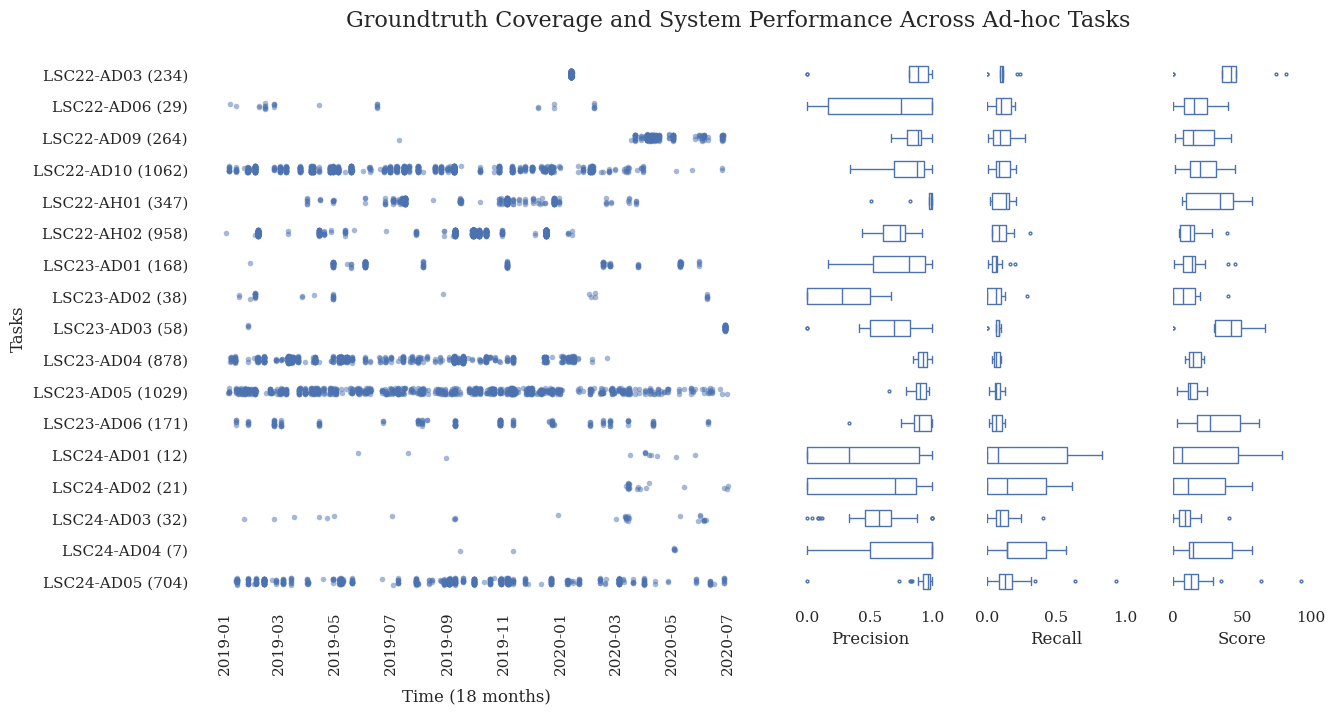

In [ ]:
from datetime import datetime
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="white")
def target_to_time(img_id):
    # remove extension
    img_id = img_id.split(".")[0]
    # remove dir
    img_id = img_id.split("/")[-1]
    # convert to datetime
    return datetime.strptime(img_id, "%Y%m%d_%H%M%S_000")


# Map the targets of each task to time
time_start = datetime(2019, 1, 1)
time_end = datetime(2020, 7, 1)

fig = plt.figure(figsize=(FIGURE_SIZE_TWO_COL, FIGURE_SIZE_ONE_COL))
plt.rcParams.update(
    {
        "font.family": "serif",  # Or 'DejaVu Serif', 'Times New Roman'
        "font.size": 10,
        "pdf.fonttype": 42,  # Use TrueType fonts in PDF (not Type 3)
        "ps.fonttype": 42,
    }
)

# sort tasks by year, task_type, and name
tasks = sorted(tasks, key=lambda x: (x["year"], task_type(x["name"]), x["name"]))
# Include only adhoc
tasks = [task for task in tasks if task_type(task["name"]) == "AD"]
data = pd.DataFrame(tasks)
# Split targets (list) into multiple rows
targets = data.explode("targets")
targets["time"] = targets["targets"].apply(func=target_to_time)

# Two subplot: one for the stripplot and one small one on the right for the scores of each task
grid = gridspec.GridSpec(1, 4, width_ratios=[8, 2, 2, 2])

ax = plt.subplot(grid[0])
current_year = 2022
sns.stripplot(data=targets, x="time", y="name", dodge=True, alpha=0.5, size=4)
# rotate x-axis labels
plt.xticks(rotation=90)
# change y-axis label to include number of targets
plt.yticks(range(len(data)), [f"{task['name']} ({len(task['targets'])})" for _, task in data.iterrows()])
task_to_num_targets = {task["name"]: len(task["targets"]) for _, task in data.iterrows()}

sns.despine(left=True, bottom=True)
plt.ylabel("Tasks")

# move xlabel down a bit
plt.xlabel("Time (18 months)", labelpad=10)

ax = plt.subplot(grid[1])
scores = lsc[lsc["task_type"] == "AD"]
scores = scores[scores["novice"] == False]
# sort by targets's tasks
scores = scores.sort_values(by="task")
sns.boxplot(data=scores, x="precision", y="task", orient="h", showfliers=True, fill=False, linewidth=1, width=0.5, fliersize=2)


# remove y-axis
plt.ylabel("")
plt.yticks([])
sns.despine(left=True, bottom=True)
# add x-axis label
plt.xlabel("Precision")

ax = plt.subplot(grid[2])
scores["norm_score"] = scores.groupby("task")["score"].transform(lambda x: x / x.max() * 100)
scores["recall"] = scores["correct"] / scores['task'].transform(lambda x: task_to_num_targets[x]) 
sns.boxplot(
    data=scores,
    x="recall",
    y="task",
    orient="h",
    showfliers=True,
    fill=False,
    linewidth=1,
    width=0.5,
    fliersize=2,
)
# remove y-axis
plt.ylabel("")
plt.yticks([])
sns.despine(left=True, bottom=True)
# add x-axis label
plt.xlabel("Recall")
plt.xlim(0, 1)

ax = plt.subplot(grid[3])


sns.boxplot(
    data=scores,
    x="score",
    y="task",
    orient="h",
    showfliers=True,
    fill=False,
    linewidth=1,
    width=0.5,
    fliersize=2,
)
# remove y-axis
plt.ylabel("")
plt.yticks([])
sns.despine(left=True, bottom=True)
# add x-axis label
plt.xlabel("Score")
plt.xlim(0, 100)

my_suptitle = plt.suptitle("Groundtruth Coverage and System Performance Across Ad-hoc Tasks", y=0.95, fontsize=16)
fig.savefig(
    "graphs/targets_over_time.pdf",
    bbox_inches="tight",
    bbox_extra_artists=[my_suptitle],
)
plt.show()

/tmp/ipykernel_1720774/511045228.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_data["num_groundtruth"] = len(task["targets"])
/tmp/ipykernel_1720774/511045228.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_data["precision"] = task_data["correct"] / (task_data["correct"] + task_data["incorrect"])
/tmp/ipykernel_1720774/511045228.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

                 num_groundtruth    spread  precision    recall     score
num_groundtruth         0.000000  0.630259   0.891613  0.097103  0.202071
spread                  0.630259  0.000000   0.243249  0.129067  0.047902
precision               0.891613  0.243249   0.000000  0.716231  0.428657
recall                  0.097103  0.129067   0.716231  0.000000  0.025934
score                   0.202071  0.047902   0.428657  0.025934  0.000000


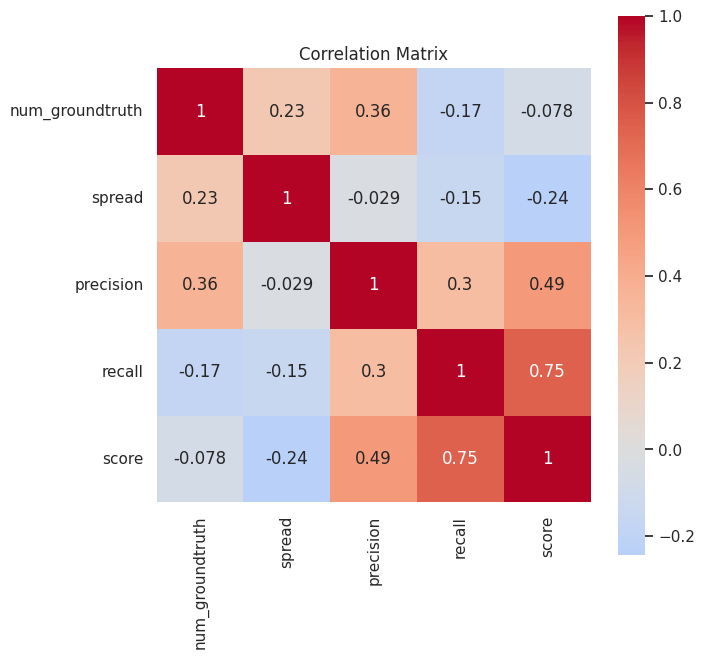

In [ ]:
from scipy.stats import entropy
from sklearn.isotonic import spearmanr

# draw correlation matrix for number of groundtruths, precision, recall, and score using previous data
all_points = pd.DataFrame()

def calculate_spread(task_name):
    times = targets[targets["name"] == task_name]["time"]
    # calculate entropy
    values = np.sort(times.astype(np.int64) // 10**9)
    n = len(values)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * values) / (n * np.sum(values))) - (n + 1) / n

def calculate_entropy(task_name):
    times = targets[targets["name"] == task_name]["time"]
    # calculate entropy
    num_bins = 20  # Adjust based on time range
    bins = np.linspace(times.min().timestamp(), times.max().timestamp(), num_bins + 1)

    # Compute histogram (frequency distribution)
    hist, _ = np.histogram(times.astype(np.int64) // 10**9, bins=bins)

    # Convert histogram counts to probabilities
    probabilities = hist / hist.sum()

    # Compute entropy (Shannon entropy)
    entropy_value = entropy(probabilities, base=2)

    return entropy_value

for task in tasks:
    task_data = lsc[lsc["task"] == task["name"]]
    task_data["num_groundtruth"] = len(task["targets"])
    task_data["precision"] = task_data["correct"] / (task_data["correct"] + task_data["incorrect"])
    task_data["recall"] = task_data["correct"] / len(task["targets"])
    task_data["spread"] = calculate_spread(task["name"])
    all_points = pd.concat([all_points, task_data])


# corr_matrix, p_values = spearmanr(all_points[["num_groundtruth", "spread", "precision", "recall", "score"]])
# print(corr_matrix)
# print(p_values)

corr_df = all_points[["num_groundtruth", "spread", "precision", "recall", "score"]]
correlation = corr_df.corr()
# calculate p-value
from scipy.stats import pearsonr

pval = correlation.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(
    len(corr_df.columns)
)
print(pval)

# plot correlation matrix
fig = plt.figure(figsize=(FIGURE_SIZE_ONE_COL, FIGURE_SIZE_ONE_COL))
sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0, square=True)
# change name of columns
plt.title("Correlation Matrix")
plt.savefig("graphs/correlation_matrix.png", dpi=300, bbox_inches='tight')

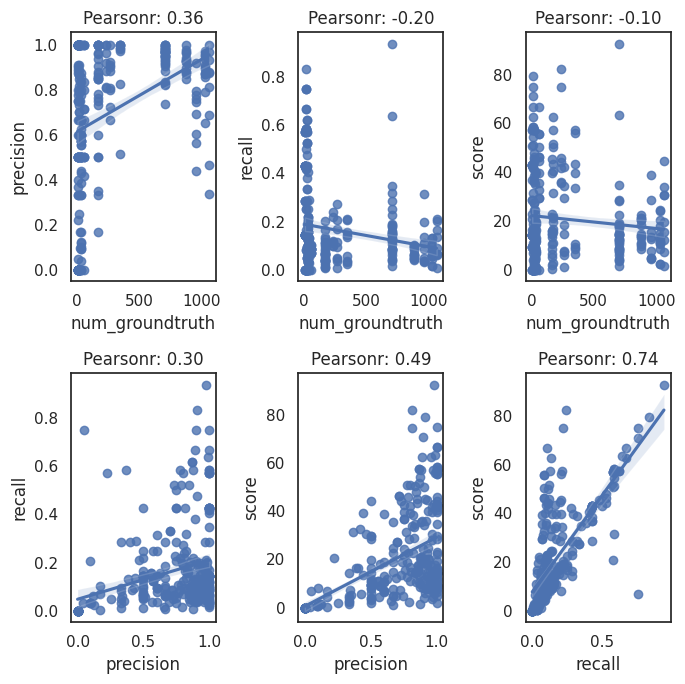

In [ ]:
# draw pearsonr for each pair

from scipy.stats import pearsonr
correlation = {}
data = all_points.dropna(subset=["num_groundtruth", "precision", "recall", "score"])
for i, col1 in enumerate(["num_groundtruth", "precision", "recall", "score"]):
    for j, col2 in enumerate(["num_groundtruth", "precision", "recall", "score"]):
        if i < j:
            correlation[(col1, col2)] = pearsonr(data[col1], data[col2])[0]

# sns.regplot(data=data, x="num_groundtruth", y="recall")
# plt.title(f"Pearsonr: {correlation[('num_groundtruth', 'precision')]:.2f}")

fig = plt.figure(figsize=(FIGURE_SIZE_ONE_COL, FIGURE_SIZE_ONE_COL))
for i, (col1, col2) in enumerate(correlation.keys()):
    ax = fig.add_subplot(2, 3, i + 1)
    sns.regplot(data=data, x=col1, y=col2, ax=ax)
    ax.set_title(f"Pearsonr: {correlation[(col1, col2)]:.2f}")
plt.tight_layout()
plt.savefig("graphs/pearsonr.png", dpi=300, bbox_inches='tight')

In [ ]:
qa_tasks = [task for task in lsc_tasks if "QA" in task["name"]]

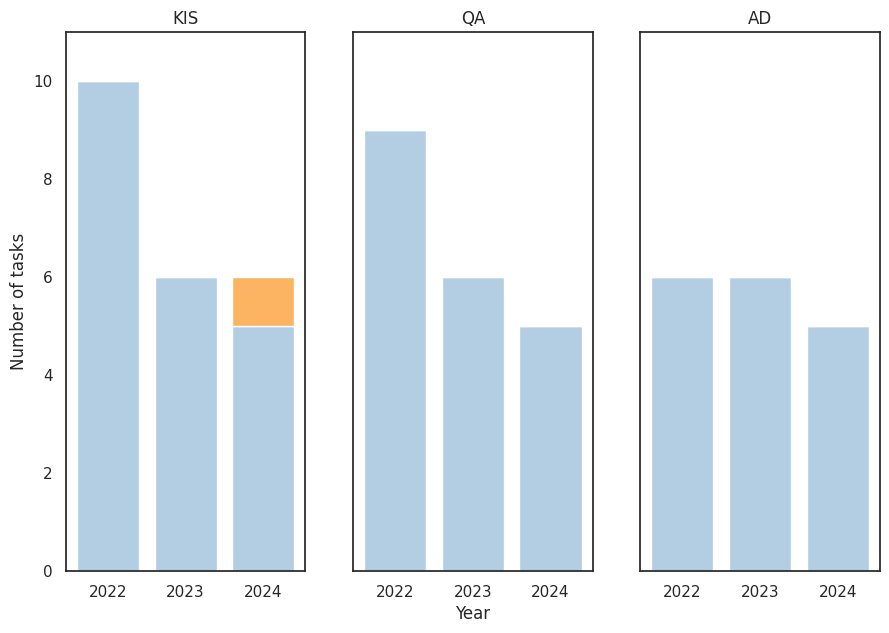

In [ ]:
# Number of solved tasks by task type per year
def is_task_solved(task_name):
    return lsc[lsc["task"] == task_name]["correct"].sum() > 0
data = pd.DataFrame(lsc_tasks)
data["solved"] = data["name"].apply(is_task_solved)
data["task_type"] = data["name"].apply(task_type)
fig = plt.figure(figsize=(FIGURE_SIZE_ONE_COL * 1.5, FIGURE_SIZE_ONE_COL))
# Bar chart solved vs unsolved tasks
for i, task in enumerate(data["task_type"].unique()):
    ax = fig.add_subplot(1, 3, i + 1)
    # stack solved and unsolved by year
    solved = data[data["task_type"] == task].groupby("year")["solved"].sum()
    unsolved = data[data["task_type"] == task].groupby("year")["solved"].count() - solved
    ax.bar(solved.index, solved, label="Solved", color=Color.blue.value)
    ax.bar(unsolved.index, unsolved, bottom=solved, label="Unsolved", color=Color.orange.value)
    ax.set_title(task)
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of tasks")
    ax.set_ylim(0, 11)
    if i == 0:
        ax.set_ylabel("Number of tasks")
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])
    if i == 1:
        ax.set_xlabel("Year")
    else:
        ax.set_xlabel("")


# Techniques vs performance

In [ ]:
# Reconstructing a unified techniques table clearly indicating features per year
systems_data = [
    ("MyScéal", 2022, "Yes", "No", "Moderate", "No"),
    ("vitrivr", 2022, "Yes", "No", "Moderate", "Yes"),
    ("vitrivr-VR", 2022, "No", "No", "Complex", "Yes"),
    ("lifeXplore", 2022, "No", "No", "Moderate", "Yes"),
    ("LifeSeeker", 2022, "Yes", "No", "Moderate", "No"),
    ("Voxento", 2022, "Yes", "No", "Moderate", "Yes"),
    ("FIRST", 2022, "No", "No", "Moderate", "Yes"),
    ("Memento", 2022, "Yes", "No", "Moderate", "No"),
    ("Memoria", 2022, "No", "No", "Moderate", "No"),
    # LSC 2023
    ("MyScéal", 2023, "Yes", "No", "Moderate", "No"),
    ("MyEachtra", 2023, "Yes", "No", "Moderate", "No"),
    ("lifeXplore", 2023, "Yes", "No", "Moderate", "Yes"),
    ("Memoria", 2023, "Yes", "No", "Moderate", "No"),
    ("Memento", 2023, "Yes", "No", "Moderate", "No"),
    ("LifeSeeker", 2023, "Yes", "No", "Moderate", "No"),
    ("LifeGraph", 2023, "Yes", "No", "Complex", "Yes"),
    ("Voxento", 2023, "Yes", "No", "Moderate", "Yes"),
    ("FIRST", 2023, "Yes", "No", "Moderate", "Yes"),
    ("vitrivr-Hybrid", 2023, "Yes", "No", "Complex", "Yes"),
    ("MemoriEase", 2023, "Yes", "No", "Moderate", "No"),
    ("LifeInsight", 2023, "Yes", "No", "Moderate", "No"),
    ("LifeLens", 2023, "No", "No", "Minimal", "No"),
    # LSC 2024
    ("LifeInsight", 2024, "Yes", "No", "Moderate", "No"),
    ("vitrivr-VR", 2024, "Yes", "No", "Complex", "Yes"),
    ("MemoriEase", 2024, "Yes", "Yes", "Moderate", "No"),
    ("EAGLE", 2024, "Yes", "No", "Complex", "No"),
    ("SnapSeek", 2024, "Yes", "No", "Moderate", "No"),
    ("VitaChronicle", 2024, "No", "No", "Minimal", "No"),
    ("Retrospect", 2024, "Yes", "No", "Minimal", "No"),
    ("LifeLens", 2024, "Yes", "No", "Minimal", "No"),
    ("vitrivr", 2024, "Yes", "No", "Moderate", "Yes"),
    ("LifeSeeker", 2024, "Yes", "No", "Moderate", "No"),
    ("VISIONE", 2024, "Yes", "No", "Moderate", "Yes"),
    ("lifeXplore 2024", 2024, "Yes", "No", "Moderate", "No"),
    ("Libro", 2024, "Yes", "No", "Moderate", "No"),
    ("CollaXRSearch", 2024, "Yes", "No", "Complex", "Yes"),
    ("Memento", 2024, "Yes", "Yes", "Moderate", "No"),
    ("LifeGraph", 2024, "Yes", "No", "Complex", "Yes"),
    ("MyEachtra", 2024, "Yes", "Yes", "Moderate", "No"),
    ("Memoria", 2024, "No", "Yes", "Moderate", "No"),
    ("Voxento", 2024, "Yes", "Yes", "Moderate", "Yes"),
    ("PraK", 2024, "No", "No", "Moderate", "No"),
    ("Exquisitor", 2024, "Yes", "No", "Moderate", "No"),
]

# Creating DataFrame
techniques_df = pd.DataFrame(
    systems_data,
    columns=[
        "team",
        "year",
        "Embedding-Based Retrieval",
        "LLM Integration",
        "UI Complexity",
        "Multimodal Integration",
    ],
)

# transfer yes to 1 and no to 0
techniques_df = techniques_df.replace({"Yes": 1, "No": 0})
techniques_df = techniques_df.replace({"Minimal": 0, "Moderate": 1, "Complex": 2})
techniques = techniques_df.columns[2:]

In [ ]:
techniques_df = pd.read_csv("teams_feats.csv")
techniques = techniques_df.columns[3:]

In [ ]:
# replace 2 with 1
techniques_df = techniques_df.replace(2, 1)

In [ ]:
# put techniques in team (by team and year)
merged_df = merged_teams.copy()
merged_df = merged_df[merged_df['team'].isin(techniques_df['team'])]
merged_df = pd.merge(merged_df, techniques_df, on=['team', 'year'])
merged_df = merged_df.dropna(subset=['precision','score'])

In [ ]:
# Function to calculate correlation per task type
from regex import F
from sklearn.isotonic import spearmanr

def correlation_per_task(i, task_type, year, merged_df, fig):
    task_df = merged_df[merged_df["task_type"] == task_type]
    task_df = task_df[task_df["year"] == year]

    correlation_columns = ["score"] + list(techniques)
    correlation_data = task_df[correlation_columns].dropna()

    corr_matrix, p_values = spearmanr(correlation_data)
    try:
        # just print the one for score
        print("-----------------")
        print(f"Task type: {task_type}, Year: {year}")
        for j, column in enumerate(correlation_columns):
            print(f"{column}: {corr_matrix[0, j]:.2f} (p={p_values[0, j]:.2f})")
    except:
        pass

fig = plt.figure(figsize=(FIGURE_SIZE_ONE_COL * 3, FIGURE_SIZE_ONE_COL))
# Perform correlation analysis for each task type
for year in [2022, 2023, 2024]:
    for i, task in enumerate(["AD", "KIS", "QA"]):
        correlation_per_task(i, task, year, merged_df, fig)

-----------------
Task type: AD, Year: 2022
-----------------
Task type: KIS, Year: 2022
-----------------
Task type: QA, Year: 2022
-----------------
Task type: AD, Year: 2023
-----------------
Task type: KIS, Year: 2023
-----------------
Task type: QA, Year: 2023
-----------------
Task type: AD, Year: 2024
score: 1.00 (p=0.00)
Ensemble Models (CLIP, BLIP2): 0.13 (p=0.06)
Integration of LLMs: -0.13 (p=0.06)
Conversational Interfaces: -0.12 (p=0.07)
-----------------
Task type: KIS, Year: 2024
score: 1.00 (p=0.00)
Ensemble Models (CLIP, BLIP2): 0.11 (p=0.11)
Integration of LLMs: -0.09 (p=0.18)
Conversational Interfaces: -0.09 (p=0.20)
-----------------
Task type: QA, Year: 2024
score: 1.00 (p=0.00)
Ensemble Models (CLIP, BLIP2): 0.09 (p=0.20)
Integration of LLMs: -0.07 (p=0.32)
Conversational Interfaces: -0.07 (p=0.32)


<Figure size 2100x700 with 0 Axes>

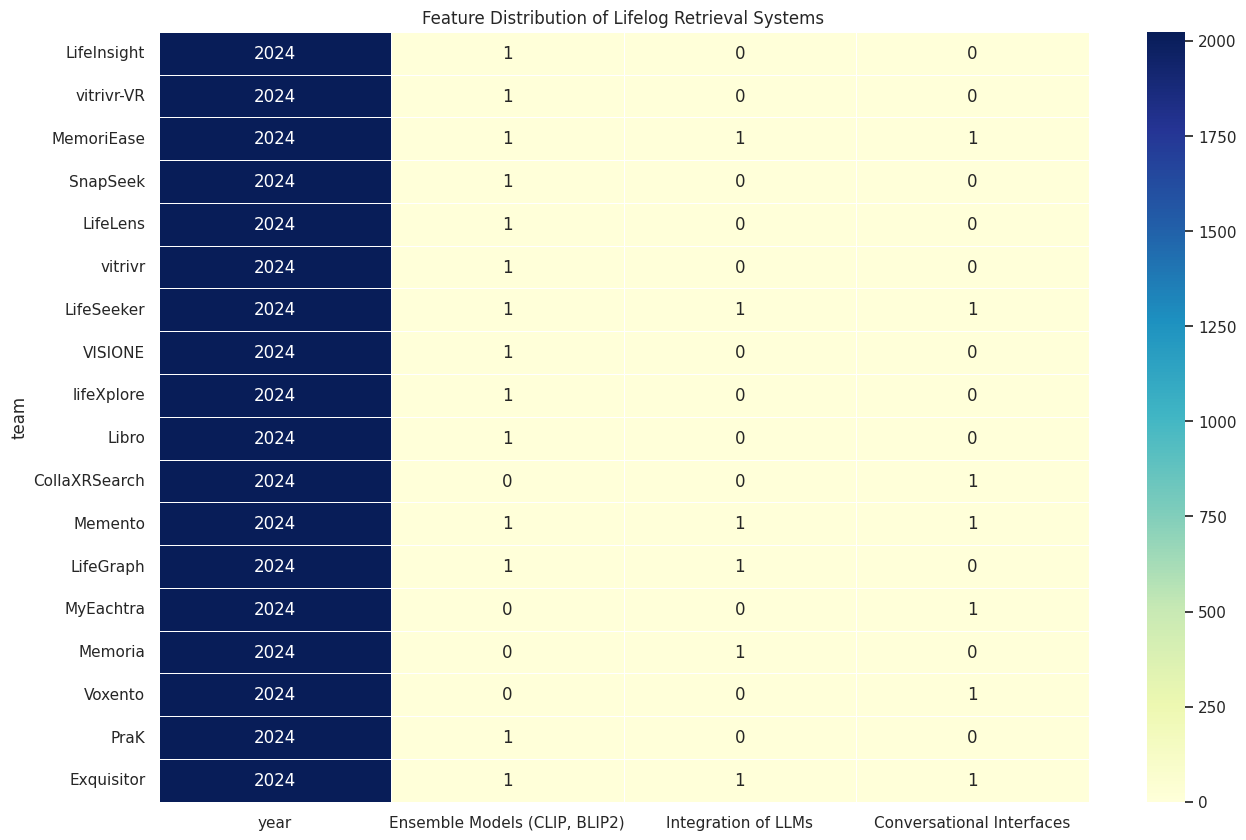

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size
plt.figure(figsize=(15, 10))

# Create a heatmap for feature distribution across different systems
sns.heatmap(
    techniques_df.set_index("team").iloc[:, 1:],
    cmap="YlGnBu",
    annot=True,
    fmt="d",
    linewidths=0.5,
)

# Set title
plt.title("Feature Distribution of Lifelog Retrieval Systems")

# Show plot
plt.show()